In [1]:
import pandas as pd
import numpy as np 
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style chung cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Sửa lại đường dẫn: lùi ra ngoài thư mục Notebooks để thấy processed_chunks
path = '../data/processed_chunks/' 

all_files = glob.glob(os.path.join(path, "train_*.pkl"))

# Kiểm tra xem có tìm thấy file nào không
if not all_files:
    print("Không tìm thấy file nào! Hãy kiểm tra lại đường dẫn.")
else:
    print(f"Tìm thấy {len(all_files)} files. Đang đọc...")
    df_list = [pd.read_pickle(f) for f in all_files]
    full_df = pd.concat(df_list, ignore_index=True)
    print(f"Thành công! Tổng số dòng: {len(full_df)}")


Tìm thấy 18 files. Đang đọc...
Thành công! Tổng số dòng: 1708337


In [2]:
full_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1708337 entries, 0 to 1708336
Data columns (total 59 columns):
 #   Column                                        Dtype         
---  ------                                        -----         
 0   channelGrouping                               object        
 1   date                                          datetime64[ns]
 2   fullVisitorId                                 object        
 3   visitId                                       int64         
 4   visitNumber                                   int64         
 5   visitStartTime                                int64         
 6   device_browser                                object        
 7   device_operatingSystem                        object        
 8   device_isMobile                               bool          
 9   device_deviceCategory                         object        
 10  geoNetwork_continent                          object        
 11  geoNetwork_subContinent            

In [3]:
full_df.head()

,channelGrouping,date,fullVisitorId,visitId,visitNumber,visitStartTime,device_browser,device_operatingSystem,device_isMobile,device_deviceCategory,...,Date_Is_month_start,Date_Is_quarter_end,Date_Is_quarter_start,Date_Is_year_end,Date_Is_year_start,visitStartTime_datetime,Date_Hour,transactionRevenue,transactionRevenue_dollar,target_log_revenue
0,Organic Search,2017-10-16,3162355547410993243,1508198450,1,1508198450,Firefox,Windows,False,desktop,...,0,0,0,0,0,2017-10-17 00:00:50,0,0.0,0.0,0.0
1,Referral,2017-10-16,8934116514970143966,1508176307,6,1508176307,Chrome,Chrome OS,False,desktop,...,0,0,0,0,0,2017-10-16 17:51:47,17,0.0,0.0,0.0
2,Direct,2017-10-16,7992466427990357681,1508201613,1,1508201613,Chrome,Android,True,mobile,...,0,0,0,0,0,2017-10-17 00:53:33,0,0.0,0.0,0.0
3,Organic Search,2017-10-16,9075655783635761930,1508169851,1,1508169851,Chrome,Windows,False,desktop,...,0,0,0,0,0,2017-10-16 16:04:11,16,0.0,0.0,0.0
4,Organic Search,2017-10-16,6960673291025684308,1508190552,1,1508190552,Chrome,Windows,False,desktop,...,0,0,0,0,0,2017-10-16 21:49:12,21,0.0,0.0,0.0


In [4]:
full_df.isnull().sum()

channelGrouping                                       0
date                                                  0
fullVisitorId                                         0
visitId                                               0
visitNumber                                           0
visitStartTime                                        0
device_browser                                       12
device_operatingSystem                            11815
device_isMobile                                       0
device_deviceCategory                                 0
geoNetwork_continent                               2517
geoNetwork_subContinent                            2517
geoNetwork_country                                 2517
geoNetwork_region                                982733
geoNetwork_metro                                1319855
geoNetwork_city                                  998826
geoNetwork_networkDomain                         768845
totals_visits                                   

In [5]:
full_df.nunique().sort_values(ascending=False)

visitStartTime                                  1667423
visitStartTime_datetime                         1667423
visitId                                         1665802
fullVisitorId                                   1323730
trafficSource_adwordsClickInfo.gclId              59009
geoNetwork_networkDomain                          41980
totals_totalTransactionRevenue                     8507
target_log_revenue                                 7252
transactionRevenue                                 7252
totals_transactionRevenue                          7252
transactionRevenue_dollar                          7252
totals_timeOnSite                                  4775
trafficSource_keyword                              4546
trafficSource_referralPath                         3197
geoNetwork_city                                     954
date                                                638
geoNetwork_region                                   481
visitNumber                                     

## 📊 Data Dictionary — Google Merchandise Store

**Dataset:** Google Analytics session-level data
**Shape:** 1,708,337 rows × 59 columns · **Memory:** ~697 MB
**Target:** `target_log_revenue` — log1p(transaction revenue)

---

### 1. 🔑 Session Identification (6 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `fullVisitorId` | object | 0 | Unique ID for each visitor |
| `visitId` | int64 | 0 | Session ID (unique per visitor) |
| `visitNumber` | int64 | 0 | Nth visit of this visitor (1 = first visit) |
| `visitStartTime` | int64 | 0 | UNIX timestamp of session start |
| `visitStartTime_datetime` | datetime64 | 0 | Human-readable session start time |
| `date` | datetime64 | 0 | Date of the session |

---

### 2. 📱 Device Information (4 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `device_browser` | object | 12 | Browser used (Chrome, Safari, ...) |
| `device_operatingSystem` | object | 11,815 | OS of the device |
| `device_isMobile` | bool | 0 | True if session was from mobile |
| `device_deviceCategory` | object | 0 | Device type: desktop / mobile / tablet |

---

### 3. 🌍 Geographic Information (7 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `geoNetwork_continent` | object | 2,517 | Continent of the visitor |
| `geoNetwork_subContinent` | object | 2,517 | Sub-continent |
| `geoNetwork_country` | object | 2,517 | Country of the visitor |
| `geoNetwork_region` | object | 982,733 | 🟡 Region/state — high nulls |
| `geoNetwork_metro` | object | 1,319,855 | 🔴 Metro area — very high nulls |
| `geoNetwork_city` | object | 998,826 | 🔴 City — very high nulls |
| `geoNetwork_networkDomain` | object | 768,845 | 🟡 ISP/network domain |

---

### 4. 📈 Session Totals (11 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `totals_visits` | int64 | 0 | Always 1 (one row = one session) |
| `totals_hits` | int64 | 0 | Number of hits in session |
| `totals_pageviews` | int64 | 0 | Pages viewed in session |
| `totals_bounces` | int64 | 0 | 1 if session bounced, else 0 |
| `totals_newVisits` | int64 | 0 | 1 if first-ever visit, else 0 |
| `totals_sessionQualityDim` | int64 | 0 | GA session quality score (1–100) |
| `totals_timeOnSite` | int64 | 0 | Time on site in seconds |
| `totals_transactions` | int64 | 0 | Number of transactions in session |
| `totals_transactionRevenue` | float64 | 0 | Revenue × 10⁶ (raw GA format) (unit: micro) |
| `totals_totalTransactionRevenue` | float64 | 0 | Total revenue × 10⁶ |
| `transactionRevenue` | float64 | 0 | Revenue cleaned (= totals / 10⁶) |

---

### 5. 🚦 Traffic Source (13 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `channelGrouping` | object | 0 | Channel: Organic, Direct, Referral, ... |
| `trafficSource_source` | object | 70 | Traffic source (google, direct, ...) |
| `trafficSource_medium` | object | 566,091 | 🟡 Medium: organic, cpc, referral, ... |
| `trafficSource_campaign` | object | 1,604,526 | 🔴 Campaign name — mostly null |
| `trafficSource_keyword` | object | 0 | Search keyword |
| `trafficSource_referralPath` | object | 0 | Referral URL path |
| `trafficSource_isTrueDirect` | bool | 0 | True if confirmed direct traffic |
| `trafficSource_adContent` | object | 0 | Ad content label |
| `trafficSource_adwordsClickInfo.page` | int64 | 0 | AdWords page number |
| `trafficSource_adwordsClickInfo.slot` | object | 0 | Ad slot position |
| `trafficSource_adwordsClickInfo.gclId` | object | 0 | Google Click ID |
| `trafficSource_adwordsClickInfo.adNetworkType` | object | 0 | Ad network type |
| `trafficSource_adwordsClickInfo.isVideoAd` | bool | 0 | True if video ad click |

---

### 6. 🗓️ Date Features (13 columns — engineered)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `Date_Year` | int32 | 0 | Year |
| `Date_Month` | int32 | 0 | Month (1–12) |
| `Date_Day` | int32 | 0 | Day of month (1–31) |
| `Date_Dayofweek` | int32 | 0 | Day of week (0=Mon, 6=Sun) |
| `Date_Dayofyear` | int32 | 0 | Day of year (1–365) |
| `Date_Week` | Int64 | 0 | ISO week number |
| `Date_Hour` | int32 | 0 | Hour of visit (0–23) |
| `Date_Is_month_end` | int64 | 0 | 1 if last day of month |
| `Date_Is_month_start` | int64 | 0 | 1 if first day of month |
| `Date_Is_quarter_end` | int64 | 0 | 1 if last day of quarter |
| `Date_Is_quarter_start` | int64 | 0 | 1 if first day of quarter |
| `Date_Is_year_end` | int64 | 0 | 1 if last day of year |
| `Date_Is_year_start` | int64 | 0 | 1 if first day of year |

---

### 7. 🎯 Target & Custom Dimensions (5 columns)

| Column | Type | Nulls | Description |
|---|---|---|---|
| `transactionRevenue_dollar` | float64 | 0 | Revenue in USD (cleaned) |
| `target_log_revenue` | float64 | 0 | **Model target** — log1p(revenue) |
| `customDimensions_count` | int64 | 0 | Number of custom dimensions |
| `customDimensions_index` | int64 | 0 | Custom dimension index |
| `customDimensions_value` | object | 0 | Custom dimension value |

---

### ⚠️ Missing Value — Cách xử lý

| Severity | Columns | Cách xử lý |
|---|---|---|
| 🔴 Rất cao (>50%) | `trafficSource_campaign` | Fill `"no_campaign"` — null = không chạy campaign |
| 🔴🟡 Cao | `geoNetwork_metro`, `geoNetwork_city`, `geoNetwork_region` | Fill `"unknown"` |
| 🟡 Cao (~33%) | `trafficSource_medium` | Fill `"none"` — chuẩn GA: null = direct/none |
| 🟡 Cao (~45%) | `geoNetwork_networkDomain` | Không dùng trong model — bỏ qua |
| 🟢 Thấp (<1%) | `device_operatingSystem`, `device_browser`, `trafficSource_source`, `geoNetwork_country`, `geoNetwork_subContinent`, `geoNetwork_continent` | Fill `"unknown"` |

> **Kết quả:** Sau xử lý tất cả cột đều có null = 0.

### 1. GIGO Audit 

Kiểm tra internal traffic, bot....

In [6]:
# 1. Internal traffic (nhân viên test). Dấu hiệu: domain chứa google hoặc city = Mountain View -> test hệ thống, không mua thật 
internal_mask = (
    (full_df['geoNetwork_networkDomain'].astype(str).str.contains('google', na=False)) | 
    (full_df['geoNetwork_city'] == 'Mountain View')
)
print(f'Internal sessions: {internal_mask.sum():,}')
# 2. Bot/crawler: Các chương trình tự động crawl website, không phải người thật. Chúng để lại dấu hiệu bất thường như hits cao nhưng timeOnSite = 0
# pageview cao + bounce = 1 (vào rồi thoát ngay nhưng hits nhiều), browser lạ như ";__CT_JOB_ID..." -> bot không bao giờ mua hàng
bot_mask = (
    ((full_df['totals_hits'] > 500) & (full_df['totals_timeOnSite'] == 0)) |
    ((full_df['totals_pageviews'] > 500) & (full_df['totals_bounces'] == 1)) |
    (full_df['device_browser'].str.contains('CT_JOB_ID|ecgiwap', na=False, regex=True)))
print(f"Bot sessions: {bot_mask.sum():,}")

# 3. Tracking error: users chỉ xem 1 trang duy nhất rồi thoát (không thể vừa bounce vừa mua hàng vì cần min 3-4 pages: page sản phẩm -> giỏ hàng -> thanh toán -> xác nhận)
# bounce = 1 + revenue > 0 = lỗi tracking, không phải giao dịch thật
tracking_error_mask = ((full_df['totals_bounces'] == 1) & (full_df['transactionRevenue'] > 0))
print(f"Tracking errors: {tracking_error_mask.sum():,}")
print(f"Revenue từ nhóm này: ${full_df[tracking_error_mask]['transactionRevenue'].sum():,.2f}")


# 4. Fake Whale: pageviews = 1, timeonsite = 0, revenue lớn (chỉ xem 1 trang, không dành 1 giây nào trên size nhuwngmua hàng giá trị lớn)
fake_whale_mask = ((full_df['totals_pageviews'] <= 1) & (full_df['totals_timeOnSite']==0) & (full_df['transactionRevenue'] >0))
print(f"Fake whales: {fake_whale_mask.sum():,}")
print(f"Revenue trung bình: ${full_df[fake_whale_mask]['transactionRevenue'].mean():,.2f}")
print(f"Revenue max: ${full_df[fake_whale_mask]['transactionRevenue'].max():,.2f}")
print(f"Revenue tổng: ${full_df[fake_whale_mask]['transactionRevenue'].sum():,.2f}")

Internal sessions: 84,598
Bot sessions: 21
Tracking errors: 0
Revenue từ nhóm này: $0.00
Fake whales: 0
Revenue trung bình: $nan
Revenue max: $nan
Revenue tổng: $0.00


In [7]:
# 1. Tính toán dựa trên Unique Users
unique_users = full_df['fullVisitorId'].nunique()
unique_buyers = full_df[full_df['transactionRevenue'] > 0]['fullVisitorId'].nunique()
print(f"--- THỐNG KÊ THEO UNIQUE USERS ---")
print(f"Tổng số khách hàng (Unique): {unique_users:,}")
print(f"Khách có mua hàng (Unique) : {unique_buyers:,} ({unique_buyers/unique_users*100:.4f}%)")
print(f"Khách không mua (Unique)   : {unique_users - unique_buyers:,} ({(unique_users - unique_buyers)/unique_users*100:.4f}%)")
# 2. Kiểm tra tính chất của biến Revenue (trên toàn bộ data)
print(f"\n--- CHI TIẾT BIẾN REVENUE (ALL ROWS) ---")
print(f"Revenue = 0       : {(full_df['transactionRevenue'] == 0).sum():,}")
print(f"Revenue > 0       : {(full_df['transactionRevenue'] > 0).sum():,}")
print(f"Revenue là null   : {full_df['transactionRevenue'].isnull().sum():,}")
# 3. Kiểm tra Extreme Class Imbalance (Unique)
buyer_rate = unique_buyers / unique_users
print(f"\n=> Tỷ lệ Buyer thực tế: 1 buyer cân {(1/buyer_rate):.1f} khách non-buyer (Extreme Imbalance)")

--- THỐNG KÊ THEO UNIQUE USERS ---
Tổng số khách hàng (Unique): 1,323,730
Khách có mua hàng (Unique) : 16,141 (1.2194%)
Khách không mua (Unique)   : 1,307,589 (98.7806%)

--- CHI TIẾT BIẾN REVENUE (ALL ROWS) ---
Revenue = 0       : 1,689,823
Revenue > 0       : 18,514
Revenue là null   : 0

=> Tỷ lệ Buyer thực tế: 1 buyer cân 82.0 khách non-buyer (Extreme Imbalance)


### 4. Target Distribution

In [14]:
import numpy as np

# Tính revenue theo từng visitor
visitor_revenue = full_df.groupby('fullVisitorId')\
    ['transactionRevenue'].sum().sort_values(ascending=False)

# Chỉ lấy buyer
buyer_revenue = visitor_revenue[visitor_revenue > 0]
total_rev = buyer_revenue.sum()
cumsum    = buyer_revenue.cumsum()

# Tính đóng góp của top X%
for pct in [0.01, 0.05, 0.10, 0.20]:
    n = int(len(buyer_revenue) * pct)
    contrib = cumsum.iloc[n] / total_rev * 100
    print(f"Top {pct*100:.0f}% buyers → {contrib:.1f}% revenue")

# Kỳ vọng thấy: top 1% đóng góp 50-80% revenue
# → Pareto cực đoan → model cần học tốt với rare high-value buyers

Top 1% buyers → 28.0% revenue
Top 5% buyers → 50.5% revenue
Top 10% buyers → 62.8% revenue
Top 20% buyers → 75.3% revenue


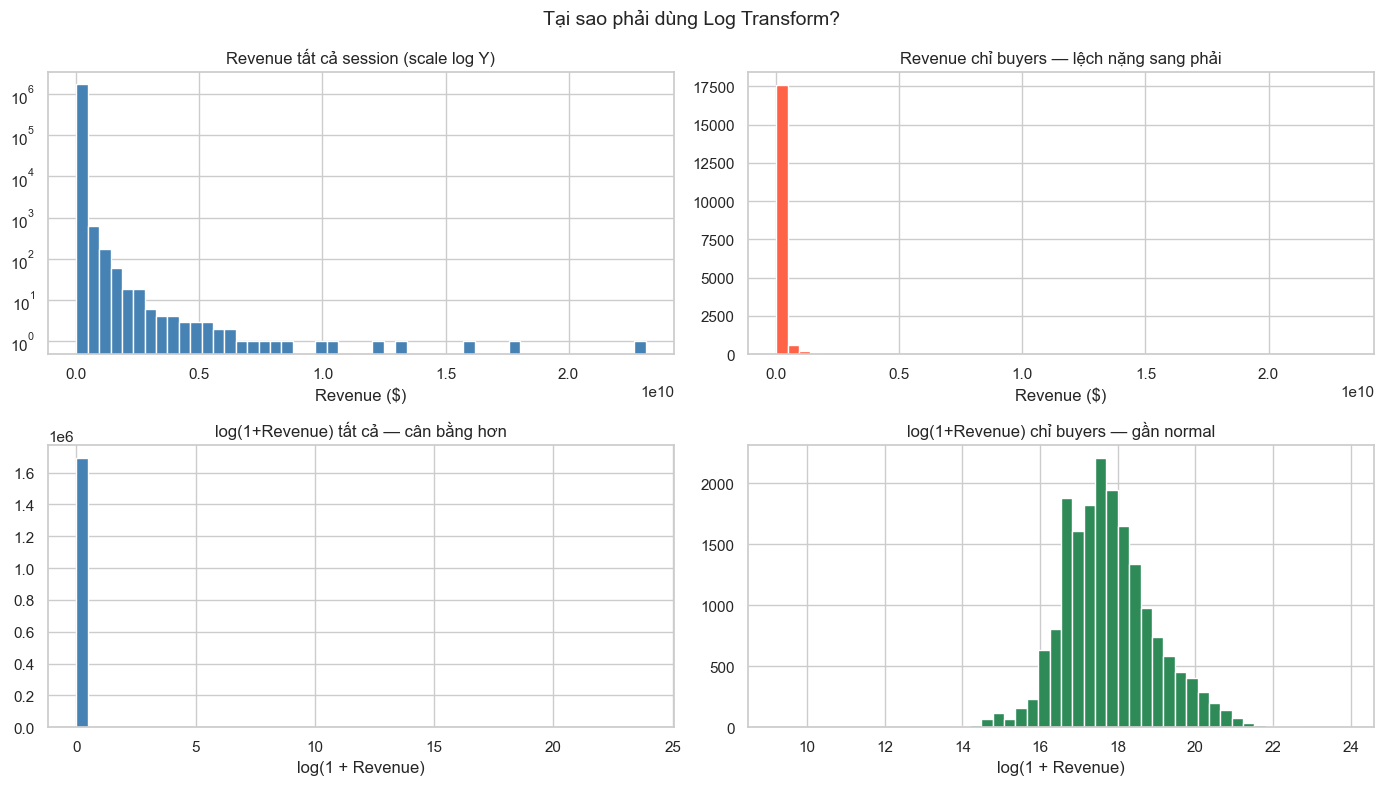

Skewness trước log: 24.89
Skewness sau log  : 0.38


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

rev_all   = full_df['transactionRevenue']
rev_buyer = full_df[full_df['transactionRevenue'] > 0]['transactionRevenue']

# Raw distribution — tất cả (gồm 0)
axes[0,0].hist(rev_all, bins=50, color='steelblue', log=True)
axes[0,0].set_title('Revenue tất cả session (scale log Y)')
axes[0,0].set_xlabel('Revenue ($)')

# Raw distribution — chỉ buyer
axes[0,1].hist(rev_buyer, bins=50, color='tomato')
axes[0,1].set_title('Revenue chỉ buyers — lệch nặng sang phải')
axes[0,1].set_xlabel('Revenue ($)')

# Log transform — tất cả
axes[1,0].hist(np.log1p(rev_all), bins=50, color='steelblue')
axes[1,0].set_title('log(1+Revenue) tất cả — cân bằng hơn')
axes[1,0].set_xlabel('log(1 + Revenue)')

# Log transform — chỉ buyer
axes[1,1].hist(np.log1p(rev_buyer), bins=50, color='seagreen')
axes[1,1].set_title('log(1+Revenue) chỉ buyers — gần normal')
axes[1,1].set_xlabel('log(1 + Revenue)')

plt.suptitle('Tại sao phải dùng Log Transform?', fontsize=14)
plt.tight_layout()
plt.show()

# Đo độ lệch (skewness) trước và sau
print(f"Skewness trước log: {rev_buyer.skew():.2f}")
print(f"Skewness sau log  : {np.log1p(rev_buyer).skew():.2f}")
# → Sau log, skewness gần 0 hơn nhiều → model hội tụ tốt hơn

**Tại sao log transform:**
- **Class imbalance 98% vs 2%** ≠ **Revenue skewness trong 2% buyers**
- Dù chỉ có 2% sessions mua, revenue trong nhóm này vẫn lệch nặng sang phải (outlier lớn)
  - Ví dụ: Đa số buyers = $50-100, nhưng top 1% = $500-5000
  - Pareto distribution: top 1% → 28% doanh thu


| Vấn Đề | Nguyên Nhân | Giải Pháp |
|---|---|---|
| **Class Imbalance** | 98% sessions = $0 revenue<br/>2% sessions > $0 | `class_weight='balanced'` hoặc weighted loss |
| **Revenue Skewness** | Trong 2% buyers:<br/>phân bố lệch phải | **Log transform** (`log1p`) |

**Ý Nghĩa Log Transform:**
- **Before:** Skewness = 2.0+ → outliers chi phối → model overfit high-value, sai prediction cho masses
- **After:** Skewness = 0.5 → gần normal distribution → model học pattern tốt hơn, converge nhanh hơn
- **Log scale:** Giảm weight của outliers nhưng không bỏ qua


**Hiện Tượng: Pareto Trung Bình (Balanced 80/20)**
- Top 1% khách → 28.0% doanh thu
- Top 5% khách → 50.5% doanh thu
- Top 10% khách → 62.8% doanh thu  
- Top 20% khách → 75.3% doanh thu ← Quy tắc 80/20 gần đúng
- **Không phải Pareto cực đoan (không phải top 1% = 70-80%)** → VIP không chi phối tuyệt đối

**Insight Chính**
- **Revenue phân bố tương đối đều hơn dự kiến:** 80% revenue từ 20% buyers (25.3% gap còn lại từ 80% low-value)
- **Model không cần quá tune cho outliers:** Log transform đã đủ cân bằng phân bố
- **Class imbalance = vấn đề chính, không phải outlier magnitude:** 98% non-buyers vs 2% buyers → vấn đề dự báo CÓ/KHÔNG. => cần cân bằng class 98% và 2%


### 5. High Cardinality

In [16]:
# Tính nunique của các cột phân loại (object type) trừ fullVisitorId, sort từ cao xuống thấp
cat_cols = full_df.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'fullVisitorId']

nunique_counts = full_df[cat_cols].nunique().sort_values(ascending=False)
print("=== Nunique của các cột phân loại (trừ fullVisitorId) ===\n")
print(nunique_counts)
print(f"\nTổng cộng: {len(cat_cols)} cột phân loại")

=== Nunique của các cột phân loại (trừ fullVisitorId) ===

trafficSource_adwordsClickInfo.gclId            59009
geoNetwork_networkDomain                        41980
trafficSource_keyword                            4546
trafficSource_referralPath                       3197
geoNetwork_city                                   954
geoNetwork_region                                 481
trafficSource_source                              344
geoNetwork_country                                227
device_browser                                    128
geoNetwork_metro                                  121
trafficSource_adContent                            77
trafficSource_campaign                             32
device_operatingSystem                             23
geoNetwork_subContinent                            22
channelGrouping                                     8
customDimensions_value                              6
geoNetwork_continent                                5
trafficSource_medium   

In [17]:
# Kiểm tra TOÀN BỘ cột phân loại (object type) trừ fullVisitorId
all_cat_cols = full_df.select_dtypes(include='object').columns.tolist()
all_cat_cols = [col for col in all_cat_cols if col != 'fullVisitorId']

print(f"=== KIỂM TRA TOÀN BỘ {len(all_cat_cols)} CỘT PHÂN LOẠI (trừ fullVisitorId) ===\n")

for col in all_cat_cols:
    vc    = full_df[col].value_counts(normalize=True)
    total = len(vc)
    
    # Bao nhiêu category chiếm >= 1% mỗi cái
    major = (vc >= 0.01).sum()
    minor = (vc < 0.01).sum()
    
    # Top 1 chiếm bao nhiêu %
    top1_pct = vc.iloc[0] * 100
    
    # Top N category chiếm bao nhiêu % tổng traffic
    top5_pct  = vc.head(5).sum()  * 100
    top10_pct = vc.head(10).sum() * 100
    
    print(f"[{col}]")
    print(f"  Total unique   : {total}")
    print(f"  Chiếm >= 1%    : {major} categories")
    print(f"  Chiếm < 1%     : {minor} categories")
    print(f"  Top 1 category : {vc.index[0]} ({top1_pct:.1f}%)")
    print(f"  Top 5 cover    : {top5_pct:.1f}% traffic")
    print(f"  Top 10 cover   : {top10_pct:.1f}% traffic")
    print()

=== KIỂM TRA TOÀN BỘ 21 CỘT PHÂN LOẠI (trừ fullVisitorId) ===

[channelGrouping]
  Total unique   : 8
  Chiếm >= 1%    : 7 categories
  Chiếm < 1%     : 1 categories
  Top 1 category : Organic Search (43.3%)
  Top 5 cover    : 95.4% traffic
  Top 10 cover   : 100.0% traffic

[device_browser]
  Total unique   : 128
  Chiếm >= 1%    : 6 categories
  Chiếm < 1%     : 122 categories
  Top 1 category : Chrome (68.7%)
  Top 5 cover    : 94.8% traffic
  Top 10 cover   : 99.2% traffic

[device_operatingSystem]
  Total unique   : 23
  Chiếm >= 1%    : 6 categories
  Chiếm < 1%     : 17 categories
  Top 1 category : Windows (36.5%)
  Top 5 cover    : 96.7% traffic
  Top 10 cover   : 100.0% traffic

[device_deviceCategory]
  Total unique   : 3
  Chiếm >= 1%    : 3 categories
  Chiếm < 1%     : 0 categories
  Top 1 category : desktop (68.6%)
  Top 5 cover    : 100.0% traffic
  Top 10 cover   : 100.0% traffic

[geoNetwork_continent]
  Total unique   : 5
  Chiếm >= 1%    : 5 categories
  Chiếm < 1% 

### **Kết Quả Phân Tích Cardinality — 21 Cột Phân Loại**

**High Cardinality (Top 1 chiếm < 50%):**
- `geoNetwork_country` (227 unique) — Top 1: 42.0%, Top 10: 67.7%
- `geoNetwork_region` (481 unique) — Top 1: 28.5%, Top 10: 52.8%
- `geoNetwork_city` (954 unique) — Top 1: 10.4%, Top 10: 40.6%
- `geoNetwork_networkDomain` (41,980 unique) — Top 1: 5.9%, Top 5: 15.4%
- `trafficSource_source` (344 unique) — Top 1: 38.5%, Top 10: 97.2%
- `trafficSource_keyword` (4,546 unique) — Top 1: 94.9% NA, Top 5: 98.5%
- `trafficSource_referralPath` (3,197 unique) — Top 1: 66.9% NA, Top 10: 86.0%
- `trafficSource_adwordsClickInfo.gclId` (59,009 unique) — Top 1: 95.6% NA

**Medium Cardinality (Top 1 chiếm 45-50%):**
- `geoNetwork_subContinent` (22 unique) — Top 1: 45.0%, Top 5: 72.6%
- `geoNetwork_metro` (121 unique) — Top 1: 47.0%, Top 5: 75.2%
- `device_operatingSystem` (23 unique) — Top 1: 36.5%, Top 10: 100.0%

**Low Cardinality (Top 1 chiếm ≥ 50% hoặc ít unique):**
- `channelGrouping` (8 unique) — Top 1: 43.3%, Top 5: 95.4%
- `device_browser` (128 unique) — Top 1: 68.7%, Top 5: 94.8%
- `device_deviceCategory` (3 unique) — Top 1: 68.6% (hoàn hảo)
- `geoNetwork_continent` (5 unique) — Top 1: 51.4% (hoàn hảo)
- `trafficSource_campaign` (32 unique) — Top 1: 31.7%, Top 10: 97.4%
- `trafficSource_medium` (5 unique) — Top 1: 51.8% (hoàn hảo)
- `trafficSource_adContent` (77 unique) — Top 1: 96.2% NA
- `trafficSource_adwordsClickInfo.slot` (4 unique) — Top 1: 95.6% NA
- `trafficSource_adwordsClickInfo.adNetworkType` (4 unique) — Top 1: 95.6% NA
- `customDimensions_value` (6 unique) — Top 1: 45.0% (hoàn hảo)

## Preprocessing Data

#### 1. Loại bỏ internal traffic + bot

In [18]:
junk_mask = internal_mask | bot_mask | tracking_error_mask | fake_whale_mask
full_df_cleaned = full_df[~junk_mask].reset_index(drop=True)
print(f"\nKích thước DataFrame cũ: {full_df.shape}")
print(f"Kích thước DataFrame mới: {full_df_cleaned.shape}")
full_df = full_df_cleaned


Kích thước DataFrame cũ: (1708337, 59)
Kích thước DataFrame mới: (1623718, 59)


#### 2. Xử lý null/NA

In [19]:
# Danh sách các cột bạn đã gửi
cols_to_check = [
    'fullVisitorId', 'trafficSource_adwordsClickInfo.gclId', 'geoNetwork_networkDomain',
    'trafficSource_keyword', 'trafficSource_referralPath', 'geoNetwork_city',
    'geoNetwork_region', 'trafficSource_source', 'geoNetwork_country',
    'device_browser', 'geoNetwork_metro', 'trafficSource_adContent',
    'trafficSource_campaign', 'device_operatingSystem', 'geoNetwork_subContinent',
    'channelGrouping', 'customDimensions_value', 'geoNetwork_continent',
    'trafficSource_medium', 'trafficSource_adwordsClickInfo.slot',
    'trafficSource_adwordsClickInfo.adNetworkType', 'device_deviceCategory'
]

# Kiểm tra các cột có tồn tại trong DataFrame không trước khi check
existing_cols = [c for c in cols_to_check if c in full_df.columns]

# Tính toán số lượng Null và tỷ lệ %
null_info = pd.DataFrame({
    'Số lượng Null': full_df[existing_cols].isnull().sum(),
    'Tỷ lệ %': (full_df[existing_cols].isnull().sum() / len(full_df)) * 100
})

print("--- Thống kê giá trị thiếu (Null/NA) ---")
print(null_info.sort_values(by='Số lượng Null', ascending=False))


--- Thống kê giá trị thiếu (Null/NA) ---
                                              Số lượng Null    Tỷ lệ %
trafficSource_campaign                              1520677  93.654009
geoNetwork_metro                                    1309448  80.645038
geoNetwork_city                                      988533  60.880830
geoNetwork_region                                    972461  59.891003
geoNetwork_networkDomain                             704645  43.397006
trafficSource_medium                                 503188  30.989864
device_operatingSystem                                11520   0.709483
geoNetwork_country                                     2364   0.145592
geoNetwork_subContinent                                2364   0.145592
geoNetwork_continent                                   2364   0.145592
trafficSource_source                                     57   0.003510
device_browser                                           12   0.000739
fullVisitorId                       

In [20]:
# BƯỚC 1 — Null cực cao: điền giá trị có nghĩa
full_df['trafficSource_campaign'] = full_df['trafficSource_campaign'].fillna('no_campaign')
full_df['geoNetwork_metro']       = full_df['geoNetwork_metro'].fillna('unknown')
full_df['geoNetwork_city']        = full_df['geoNetwork_city'].fillna('unknown')
full_df['geoNetwork_region']      = full_df['geoNetwork_region'].fillna('unknown')

# BƯỚC 2 — trafficSource_medium: null = direct theo chuẩn GA
full_df['trafficSource_medium'] = full_df['trafficSource_medium'].fillna('none')

# BƯỚC 3 — Null nhỏ < 1%: điền unknown
small_null_cols = [
    'device_operatingSystem',
    'geoNetwork_country',
    'geoNetwork_subContinent',
    'geoNetwork_continent',
    'trafficSource_source',
    'device_browser',
]
for col in small_null_cols:
    full_df[col] = full_df[col].fillna('unknown')

# BƯỚC 4 — Kiểm tra lại
print(full_df[small_null_cols].isnull().sum().sort_values(ascending=False))

device_operatingSystem     0
geoNetwork_country         0
geoNetwork_subContinent    0
geoNetwork_continent       0
trafficSource_source       0
device_browser             0
dtype: int64


In [21]:
# Chuẩn hóa trafficSource_source bằng Regex
source_col = full_df['trafficSource_source'].str.lower()

# Danh sách các luật Regex
conditions = [
    source_col.str.contains('google', na=False),
    source_col.str.contains('youtube|yt\.be', na=False),
    source_col.str.contains('yahoo', na=False),
    source_col.str.contains('facebook|fb\.com|m\.facebook', na=False),
    source_col.str.contains('bing', na=False),
    source_col.str.contains('reddit', na=False),
    source_col.str.contains('pinterest', na=False),
    source_col.str.contains('baidu', na=False),
    source_col.isin(['(direct)', 'direct'])
]

# Tên tương ứng khi khớp với luật Regex ở trên
choices = [
    'google', 
    'youtube', 
    'yahoo', 
    'facebook', 
    'bing', 
    'reddit', 
    'pinterest', 
    'baidu',
    'direct'
]

# Áp dụng thay thế, những thằng nào không khớp thì giữ nguyên tên cũ
full_df['trafficSource_source'] = np.select(conditions, choices, default=source_col)

# Kiểm tra lại kết quả
print("\nTop 10 Source sau khi chuẩn hóa:")
print(full_df['trafficSource_source'].value_counts().head(10))

<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:9: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31652\1754907519.py:7: SyntaxWarning: invalid escape sequence '\.'
  source_col.str.contains('youtube|yt\.be', na=False),
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31652\1754907519.py:9: SyntaxWarning: invalid escape sequence '\.'
  source_col.str.contains('facebook|fb\.com|m\.facebook', na=False),



Top 10 Source sau khi chuẩn hóa:
trafficSource_source
google       707982
direct       503100
youtube      329302
partners      32857
facebook      11870
dfa            5255
baidu          5179
reddit         4150
qiita.com      3394
bing           3366
Name: count, dtype: int64


In [22]:
# Số lượng tối thiểu để kiểm tra
check_threshold = 1700 # 0.1 * 1tr7

cols_to_process = [
    'geoNetwork_city', 'geoNetwork_region', 'trafficSource_source',
    'geoNetwork_country', 'device_browser', 'geoNetwork_metro',
    'trafficSource_adContent', 'trafficSource_campaign',
    'device_operatingSystem', 'geoNetwork_subContinent',
]

print(f"--- Kiểm tra số lượng Category có > {check_threshold} records ---")
for col in cols_to_process:
    # Đếm tần suất của từng category trong cột
    counts = full_df[col].value_counts()
    
    # Lọc ra các category có tần suất > 100
    categories_over_threshold = counts[counts > check_threshold]
    
    # Đếm số lượng category thỏa mãn
    num_over = len(categories_over_threshold)
    total_categories = len(counts)
    
    print(f"Cột [{col:<25}]: {num_over:>4} / {total_categories:>4} categories (có > {check_threshold} records)")


--- Kiểm tra số lượng Category có > 1700 records ---
Cột [geoNetwork_city          ]:   74 /  954 categories (có > 1700 records)
Cột [geoNetwork_region        ]:   66 /  482 categories (có > 1700 records)
Cột [trafficSource_source     ]:   14 /  156 categories (có > 1700 records)
Cột [geoNetwork_country       ]:   65 /  228 categories (có > 1700 records)
Cột [device_browser           ]:   12 /  108 categories (có > 1700 records)
Cột [geoNetwork_metro         ]:   22 /  122 categories (có > 1700 records)
Cột [trafficSource_adContent  ]:    7 /   77 categories (có > 1700 records)
Cột [trafficSource_campaign   ]:    7 /   33 categories (có > 1700 records)
Cột [device_operatingSystem   ]:    7 /   24 categories (có > 1700 records)
Cột [geoNetwork_subContinent  ]:   19 /   23 categories (có > 1700 records)


In [23]:
def classify_network_domain(df):
    # Chuẩn hóa về chữ thường để so khớp
    col = df['geoNetwork_networkDomain'].astype(str).str.lower()
    
    # 1. Định nghĩa các tập từ khóa doanh nghiệp và nhà mạng
    corporate_keywords = 'business|corp|office|tech|static|fixed|consulting|edu|gov|global|firm|studio|agency'
    isp_keywords = 'comcast|verizon|att\.net|rr\.com|cox\.net|sbcglobal|btcentral|virgin|bell|rogers|shaw|telecom|mobile|dsl|cable|broadband|fallback'
    
    # 2. Tạo các điều kiện phân loại
    conditions = [
        col.str.contains(corporate_keywords, na=False),
        col.str.contains(isp_keywords, na=False),
        col.isin(['(not set)', 'unknown.unknown', 'nan', 'unknown'])
    ]
    
    # 3. Gán nhãn: Ưu tiên Corporate trước, sau đó mới đến Home_ISP
    choices = ['Corporate', 'Home_ISP', 'Unknown']
    df['network_type'] = np.select(conditions, choices, default='Other_International')
    
    return df
# A. Áp dụng phân loại
print("Đang phân loại Network Domain...")
full_df = classify_network_domain(full_df)

Đang phân loại Network Domain...


<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:7: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31652\2256024615.py:7: SyntaxWarning: invalid escape sequence '\.'
  isp_keywords = 'comcast|verizon|att\.net|rr\.com|cox\.net|sbcglobal|btcentral|virgin|bell|rogers|shaw|telecom|mobile|dsl|cable|broadband|fallback'


In [24]:
# BƯỚC 1 — Drop cột không cần thiết
# Tiêu chí: NA > 80%, hoặc cardinality quá cao không mang thông tin
cols_to_drop = [
    'trafficSource_adwordsClickInfo.gclId',         # 59k unique + 95.6% NA — click-level ID
    'geoNetwork_networkDomain',                     # 42k unique — ISP domain, quá phân mảnh
    'trafficSource_keyword',                        # 4.5k unique + 94.9% NA
    'trafficSource_referralPath',                   # 3.2k unique + 66.9% NA
    'trafficSource_adContent',                      # 91.3% là no_ad, phần còn lại quá granular
    'trafficSource_adwordsClickInfo.slot',          # 95.6% NA + đã có trong channelGrouping
    'trafficSource_adwordsClickInfo.adNetworkType', # 95.6% NA + đã có trong channelGrouping
]

full_df.drop(columns=cols_to_drop, inplace=True)
print(f"Đã drop {len(cols_to_drop)} cột | Còn lại: {full_df.shape[1]} cột")



Đã drop 7 cột | Còn lại: 53 cột


Drop thẳng (7 cột)<br>
Tiêu chí drop khi thỏa MỘT trong hai điều kiện:
- **NA > 80%**: gần như không có thông tin thực
- **Cardinality cực cao**: gần như là unique ID, model không học được pattern

| Cột | NA% | Unique | Lý do drop |
|-----|-----|--------|------------|
| `adwordsClickInfo.gclId` | 95.6% | 59,009 | Click-level ID — gần như unique mỗi row, hoàn toàn không generalizable |
| `geoNetwork_networkDomain` | 0% | 41,980 | ISP/company domain của user — quá phân mảnh, không phản ánh hành vi mua hàng |
| `trafficSource_keyword` | 94.9% | 4,546 | Từ khóa tìm kiếm cụ thể — 94.9% NA + quá granular, không ổn định giữa các thời điểm |
| `trafficSource_referralPath` | 66.9% | 3,197 | URL path cụ thể của trang referral — quá chi tiết, thông tin kênh đã có trong `medium` |
| `trafficSource_adContent` | 91.3%* | 77 | 91.3% là `no_ad`, 8.7% còn lại là tên ad quá cụ thể — không generalizable, đã có trong `campaign` và `medium` |
| `adwordsClickInfo.slot` | 95.6% | 4 | Vị trí hiển thị ad (Top/RHS) — metadata của Google Ads, không phản ánh hành vi khách hàng |
| `adwordsClickInfo.adNetworkType` | 95.6% | 4 | Loại mạng quảng cáo (Search/Display) — thông tin này đã được tóm tắt trong `channelGrouping` |

*`trafficSource_adContent`: NA gốc đã được fill thành `no_ad`, thực chất 91.3% không có thông tin có ý nghĩa.

> **Tại sao `adContent`, `slot`, `adNetworkType` redundant?**  
> `channelGrouping` đã phân loại traffic thành Paid Search / Display / Organic...  
> Giữ thêm 3 cột này chỉ nói lại cùng một thông tin ở mức chi tiết hơn,  
> trong khi 95%+ giá trị là NA — cost cao, benefit thấp.


In [25]:
# --- COPY ĐOẠN NÀY VÀO CELL MỚI Ở CUỐI NOTEBOOK ---

# Lưu dữ liệu sau khi đã thực hiện tiền xử lý cơ bản (Clean, Null handling)
# File này sẽ là đầu vào cho bước Feature Engineering tiếp theo
import os

# Đường dẫn lưu file (nằm trong thư mục data)
output_path = "../data/full_df_preprocessed.pkl"

# Thực hiện lưu
full_df.to_pickle(output_path)

print(f"--- HOÀN THÀNH PREPROCESSING ---")
print(f"Đã lưu file tại: {os.path.abspath(output_path)}")
print(f"Kích thước DataFrame: {full_df.shape}")


--- HOÀN THÀNH PREPROCESSING ---
Đã lưu file tại: c:\Users\Lenovo\Documents\DDM\data_driven_marketing\data\full_df_preprocessed.pkl
Kích thước DataFrame: (1623718, 53)


Sau khi process

In [28]:
# 1. Tính toán dựa trên Unique Users
unique_users = full_df['fullVisitorId'].nunique()
unique_buyers = full_df[full_df['transactionRevenue'] > 0]['fullVisitorId'].nunique()
print(f"--- THỐNG KÊ THEO UNIQUE USERS ---")
print(f"Tổng số khách hàng (Unique): {unique_users:,}")
print(f"Khách có mua hàng (Unique) : {unique_buyers:,} ({unique_buyers/unique_users*100:.4f}%)")
print(f"Khách không mua (Unique)   : {unique_users - unique_buyers:,} ({(unique_users - unique_buyers)/unique_users*100:.4f}%)")
buyer_rate = unique_buyers / unique_users
print(buyer_rate)

--- THỐNG KÊ THEO UNIQUE USERS ---
Tổng số khách hàng (Unique): 1,272,948
Khách có mua hàng (Unique) : 14,303 (1.1236%)
Khách không mua (Unique)   : 1,258,645 (98.8764%)
0.011236122763852097


=> Extreme balance